# MNE로 로우데이터 로딩부터 전처리까지, 가능하면 더 나아가기기

[순서]
1. 원시 데이터에서 이벤트 구문 분석
https://mne.tools/stable/auto_tutorials/intro/20_events_from_raw.html

# Data loading (데이터 불러오기+ 시각화; 발작 시점의 뇌파 비교)

In [1]:
# 파이썬 모듈 로딩과 함께 (RAM 메모리 절약 위해) raw 객체 60초로 분할.

import os
import numpy as np
import mne


''' 원문의 mne 자체 제공 샘플 데이터 불러오는 코드.
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
'''

# chb01 환자의 3번 파일; chb01_03.edf (seizure 있음)
raw = mne.io.read_raw_edf(
    "/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf",
    preload=True,
    verbose=False
)
raw.crop(tmax=3599).load_data() #처음 0초 ~ 3599초.(실제로 59분 59.99xx초라서 60분 꽉 채우면 인식 오류 생김.)

/tmp/ipykernel_521335/3219101755.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

이벤트 및 주석(Annotations) 데이터 구조

주석은 뇌파 기록 중 시간의 매핑과 그 시간에 발생한 이벤트에 대한 설명 제공.

STIM channel?

stimulate channel; EEG, MEG 또는 기타 센서로부터 신호를 수신하지 않는 채널. 대신, STIM 채널은 전압(DC pulse)을 기록하며, 이 펄스는 자극의 시작이나 피험자의 버튼 누름 반응과 같은 실험 사건에 시간적으로 고정됨.
이러한 펄스가 실험 사건에 시간적으로 고정되지 않고, 다음 시행에서 발생할 자극(또는 실험 조건)의 조건을 나타내기 위해 trial 사이에 발생할 수도 있음.

[단! chb db의 경우 이런 STIM 채널에 대한 정보 없음.]
ㄴ 순수하게 뇌파 기록만 하고 발작 기간으로 보이는 부분은 연구진 재량으로 직접 기록했으니까.

###
chb01_03 발작 시기.
Seizure Start Time: 2996 seconds >> 49분 56초
Seizure End Time: 3036 seconds >> 50분36초  (40초 지속)

바로 밑 코드는 전체 60분(3599초) 중 발작 발생 trial을 시각화하여 비발작 파형과의 비교 목적을 담음.
※ 최소 범위 2980~3060초 (80초) + 진폭 120 μV(=120e-6) -> 잘 보임.

1.
https://synapse.koreamed.org/upload/synapsedata/pdfdata/0055jkna/jkna-58-76.pdf
진폭은 20 μV 이하인 경우 저진폭, 20~70 μV는 중진폭, 70 μV 이상인 경우 고진폭으로 표기한다. 
2.
https://jknpa.org/doix.php?id=10.4306/jknpa.2019.58.2.76
진폭 분류로 해석할 때는 진폭의 하단값과 상단값을 알아야 한다. 다음과 같은 이상이 있다면 확인이 필요하다; __하단이 5 µV 이상, 상단이 10 µV 이상이면 정상이며__, 하단이 5 µV 이하, 상단이 10 µV 이상이면 중등도의 비정상 상태로 판단한다. 또한 하단이 5 µV 미만, 상단이 10 µV 미만이면 중증 비정상 상태로 판단한다.


그러나 작은 규격의 그래프에 장시간의 epoch이 담긴 trial을 쉽게 확인하려면(60~180초) 진폭의 척도를 매우 크게(예:120 μV) 설정해야 됨.
또, 발작이 일어나는 시점에서 이런 파형의 진폭이 아주 크게 튀는데 상하 상관 없이 70µV 이상으로 peak가 발생함. 원래 뇌전증이란 병이 이런 것인지 다시 알아봐야겠다.

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Using matplotlib as 2D backend.


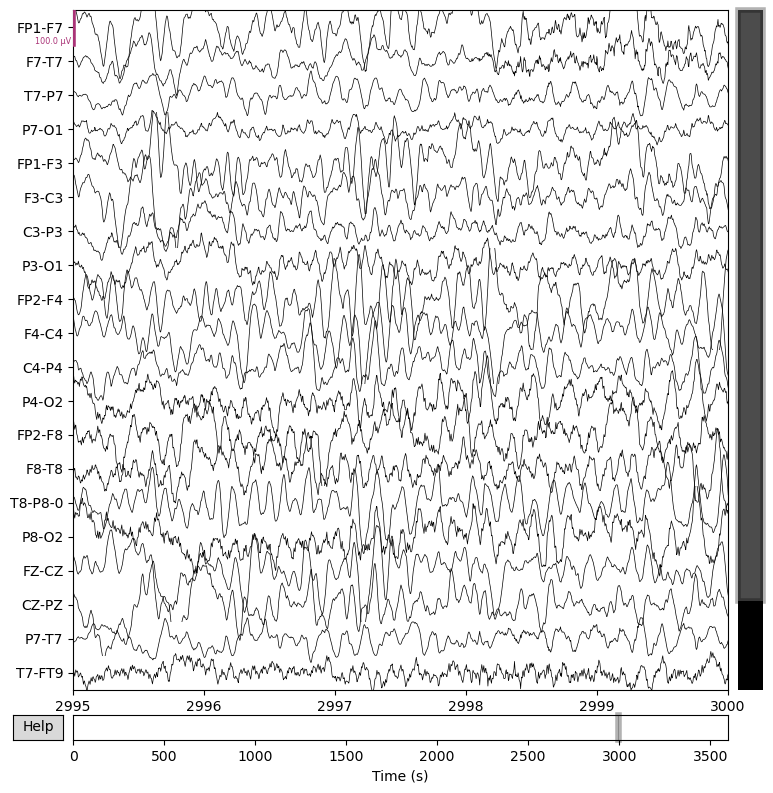

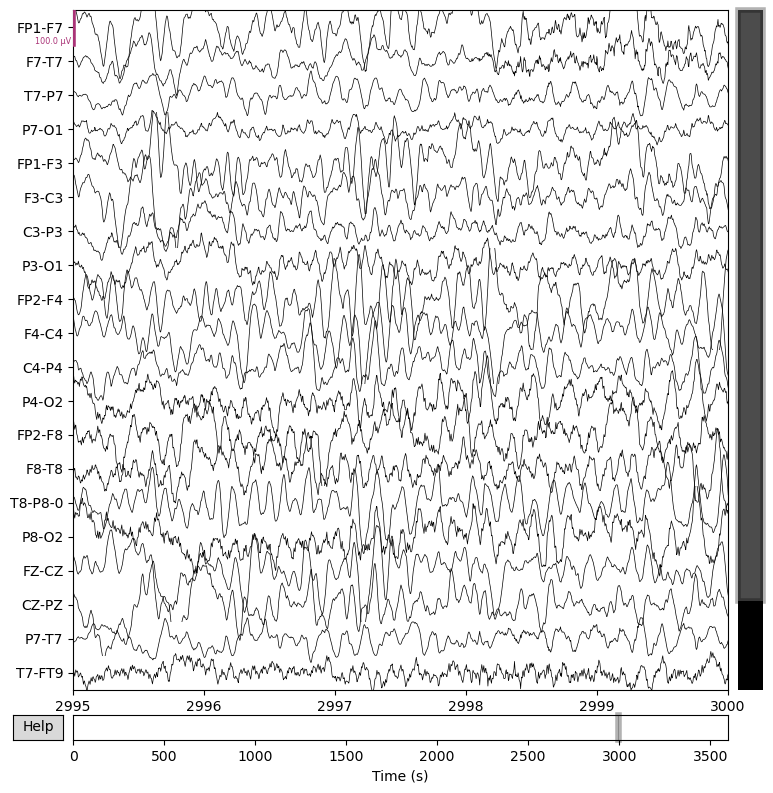

In [2]:
#대안; EEG 신호 시각화 >>> 전체 or 특정 채널 

# 이벤트 채널 종류 확인
print(raw.info['ch_names'])  # 사용 가능한 채널 목록 확인

#EEG 신호 시각화 (특정 채널만 또는 전체)
raw.copy().pick('eeg').plot(start=2995, duration=5, scalings=dict(eeg=50e-6)) 

# scalings: dict(eeg=값)으로 수동 진폭 설정 (40e-6 = 40 μV ; 4 / 10^6)

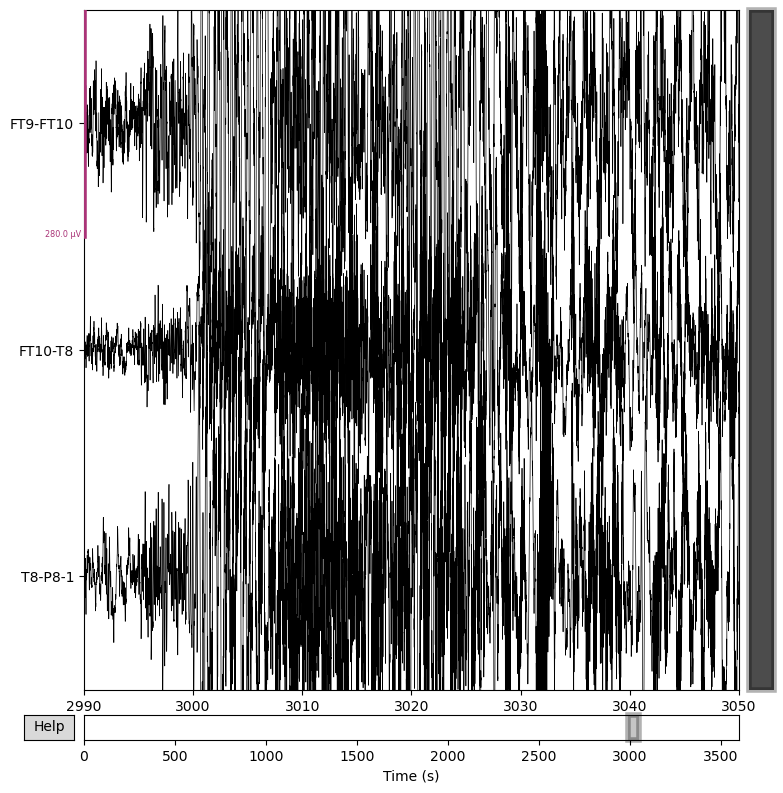

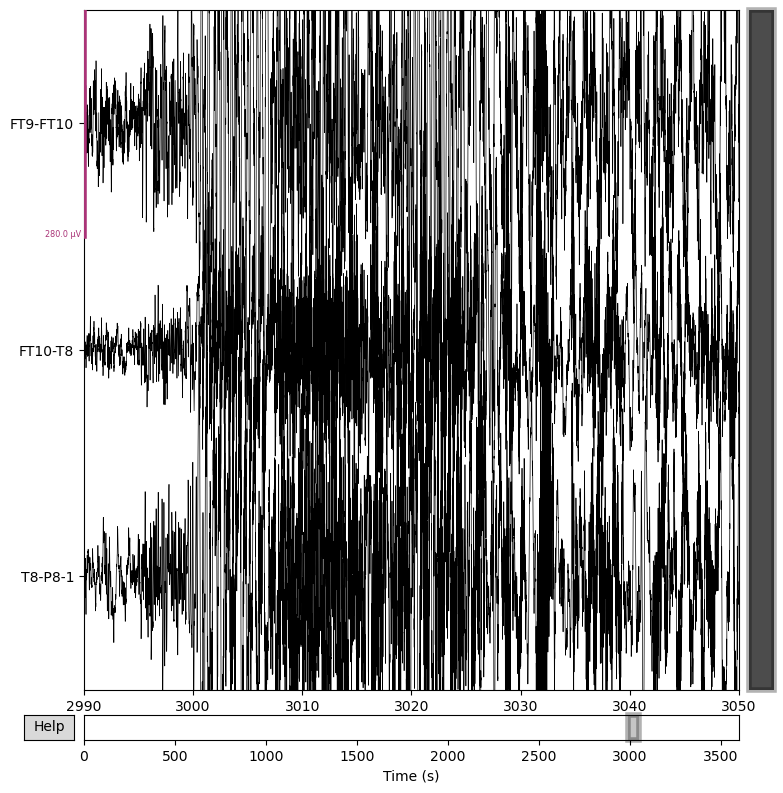

In [3]:
# 또는 채널명을 직접 선택해서 시각화; 전체 채널 그래프 중 하위 3가지가 잘림...
raw.copy().pick(['FT9-FT10', 'FT10-T8', 'T8-P8-1']).plot(start=2990, duration=60, scalings=dict(eeg=140e-6))

# 내장된 이벤트를 주석으로 읽기 >>> .seizure 표시하기?
(원문)
일부 EEG/MEG 시스템은 이벤트가 하나 이상의 STIM 채널에 펄스 형태로 저장되는 대신 별도의 데이터 배열에 저장되는 파일을 생성합니다. 예를 들어, EEGLAB 형식은 이벤트를 [.set] 파일에 배열 모음으로 저장합니다. 이러한 파일을 읽을 때 MNE-Python은 저장된 이벤트를 자동으로 Annotations 객체로 변환하여 Raw 객체의 주석 속성으로 저장합니다.

In [4]:
''' 냅다 따라하고 억지로 코드 고친 것, 폐기
eeglab_raw_file = mne.io.read_raw_eeglab(
    "/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf.seizures",
    preload=True,
    verbose=False
)
eeglab_raw = mne.io.read_raw_eeglab(eeglab_raw_file)
print(eeglab_raw.annotations)
'''

' 냅다 따라하고 억지로 코드 고친 것, 폐기\neeglab_raw_file = mne.io.read_raw_eeglab(\n    "/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf.seizures",\n    preload=True,\n    verbose=False\n)\neeglab_raw = mne.io.read_raw_eeglab(eeglab_raw_file)\nprint(eeglab_raw.annotations)\n'

>>>
[RuntimeError]: For EEGLAB I/O to work, the module pymatreader is needed, but it could not be imported. Use the following installation method appropriate for your environment:
...
    324     '''
--> 325     super().__init__(mat_stream, *args, **kwargs)
    326     self._matrix_reader = None

[TypeError]: MatFileReader.__init__() got an unexpected keyword argument 'uint16_codec'

결론: unit16 같은 거 여기 없다. 걍 다른 것을 하자.


------------------------------------------


>>> # 해결책: seizure 구간 수동으로 주석 달기
연속 데이터 주석 달기
https://mne.tools/stable/auto_tutorials/raw/30_annotate_raw.html

# 주석 수동으로 만들기

In [5]:
# 1. 모듈, 로우데이터 로드 (생략)
raw

<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

In [6]:
# 2. 발작 시점 지정

seizure_onset = 2996.0 
seizure_end = 3036.0

# 3. 주석 생성
annot = mne.Annotations(
    onset = [seizure_onset], 
    duration = [seizure_end - seizure_onset],
    description= 'seizure'
)

In [7]:
print(annot)

<Annotations | 1 segment: seizure (1)>


In [8]:
# 4. raw 객체에 주석 붙이기
raw.set_annotations(annot)

<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

# annot -> event 변환 + 시각화
이래야 epoching에 쓸 수 있음

In [9]:
# Annotations 객체에서 이벤트 추출
# 주석의 description을 기반으로 이벤트 생성
event_dict = mne.events_from_annotations(raw)           # 인수 events 삭제; 여기서는 쓸모없는것같음
print(event_dict)       # {'seizure': 1}
#print(events[:5])       # [시작 샘플,   0,    이벤트 ID] 형태

Used Annotations descriptions: ['seizure']
(array([[766976,      0,      1]]), {'seizure': 1})


In [10]:
'''
# event -> annot로 돌아가기
annot_back = mne.annotations_from_events(
    events=events,
    event_desc=event_dict,
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)
raw.set_annotations(annot_back)
'''

'\n# event -> annot로 돌아가기\nannot_back = mne.annotations_from_events(\n    events=events,\n    event_desc=event_dict,\n    sfreq=raw.info["sfreq"],\n    orig_time=raw.info["meas_date"],\n)\nraw.set_annotations(annot_back)\n'

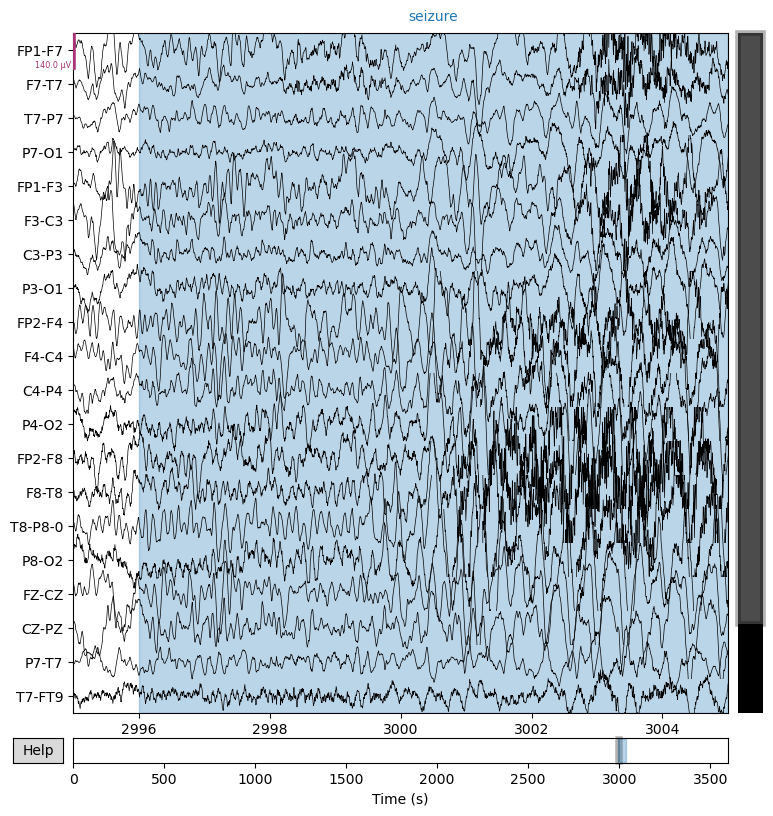

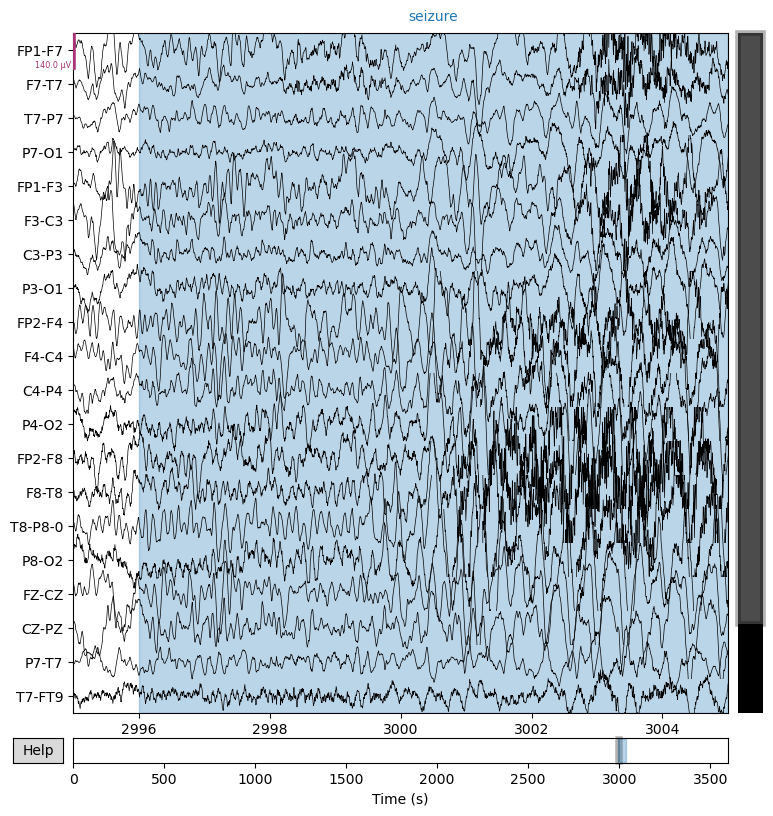

In [11]:
# 시각화 (발작 주석 표시됨)
raw.plot(start=2995, duration=10, scalings=dict(eeg=70e-6))

아 뭐하지 이제
순서부터 차근차근 정한다

1 뇌전증과 EEG 데이터 학습(오늘 안에 간단히 하면 될 것 같음)
    seizure, non-s의 power spectrum 비교 분석

2 환자 5명(1,3,5,7,9번 환자로 할까)의 파일들로 데이터 preprocseeing, time window 추출(발작 전 시간 1~2초 추출 이런 거) >>> 250604 1명의 환자(chb01)의 데이터 파일 10개 사용; 비발작:발작 = 7:3

3 train/test 데이터로 나누기 (LOO 교차검증법에 따라)

4 파이토치로 발작 감지 모델 만들기

5 모델 훈련

6 모델 평가


☆ seizure detection using EEG에 사용되는 ML 기반 알고리즘은 뭐가 있을까?
- 가우시안 혼합 모델(GMM)
    전체 집단의 하위 분포가 선형결합했을 때 가우시안 분표(=정규분포)를 따름
- 인공 신경망(ANN)
- 지원 벡터 머신(SVM)
- 최소 제곱 SVM(LS-SVM)
    SVM의 최소 제곱(오차를 최소화하는 방법으로 회귀 계수를 추정함) 버전 
- 랜덤 포레스트(RF)
- 결정 트리(DT)
- K-최근접 이웃(KNN)
- 나이브 베이즈(Naive Bayes)
    베이즈 정리(Bayes' theorem)를 기반으로 한 확률 분류 기법으로, 특성들 간의 독립성을 가정하여 분류 작업을 수행.
- K-fold 교차 검증: 데이터를 k개의 fold로 만들어 교차 검증. 데이터가 소량일 때 양을 뻥튀기시키기에 딱임.
훈련(train 과정)
    1. 한 데이터를 여러 조각냈을 때의 한 조각, 나중에 이 flod도 k개의 더 작은 낱개로 쪼개짐. k개의 작은 데이터 조각 중 k-1개는 training, 마지막 1개가 validation의 쓰임.
    2. 모델 예측 진행 >> 오류값 추출
    3. 다음 fold에서 valid-set 바꾸고 이전의 valid용 fold의 역할이 train용이 됨 >>> 과정 k번 반복
평가(test) 과정
    4. 각 fold별 시도에서 기록된 오류를 바탕으로 모델의 최적의 조건 찾음
    5. 그 조건으로 전체 training set 학습 진행
    6. 처음에 분할했던 test set로 모델 평가

ML 기반 발작 감지법은 높은 정확도 달성 가능. 하지만...
1. 최적의 특징과 분류기를 수동으로 선택해야 함
2. 특징 추출은 시간 소요 큼 >> 실제 적용 시 모델 효율성 저하 가능
>>> 딥 러닝의 등장으로 극복

https://scikit-learn.org/stable/modules/cross_validation.html
(사이킷런-교차검증 설명서 참조)

### 실험 설계(단, 완전 개발새발 수준)

CHB 데이터 어케 나눠야 할까....
0. 전제조건: 1명(chb01)의 데이터 9개로 or  3명(chb01,03,05)의 데이터 각각 3개로 교차 검증
※ 단순 TVT는 단일 데이터 분할을 하지 않으므로 고성능 모델을 훈련하기 어려울 뿐더러 여타 seizure detection 논문 방식에 어긋남. LOO 교차검증법 적용하기
>>> chb01의 데이터 파일 10개 사용(비발작: 발작=7:3)

1. 그냥 chb01 환자의 데이터 비발작, 발작 파일 잘 섞어서 9개(양 늘릴 수 있음) 골라내고 이걸 감지 모델(나중에 만들 거임 ㅋㅋ)이 잘 받아먹는 형식으로 가공
- 파일 9개를 선정해서 180초 분량으로 epoching하고(1~4시간짜리 원본을 읽게 하기에는 cpu가 못 버틸 것 같음) 모델 학습용 폴더 따로 만들어 저장
    - 비발작 파일: 아무 곳이나 에폭 지정해서 180초 분량으로 추출
    - 발작 파일: seizure event가 포함되도록 180초 분량으로 추출
    >>> 위의 방식으로 추려낸 파일들을 새 폴더에 저장(T-V-T가 각각 혼용되지 않도록 하기. 근데 어케 하지;;)

2. detection 코드 만들기; 각 파일 전체를 읽고 이상치(anomaly; seizure event)가 한 번이라도 있으면 발작이 일어났다고 판정(1), 한 번도 없었으면 0으로 판정.

https://braindecode.org/stable/auto_examples/applied_examples/plot_tuh_eeg_corpus.html
얘를 참조해볼까..(빅데이터 EEG 리소스(TUH EEG Corpus) 처리)


# Pre-procsee + TVT split

In [12]:
import os
import mne
import numpy as np
from pathlib import Path
from sklearn.model_selection import KFold, LeaveOneOut
from braindecode.datasets import create_from_mne_raw    # from braindecode.datautil >> to from braindecode.datasets
from braindecode.datasets import BaseConcatDataset

# UserWarning: create_from_mne_raw has been moved to datasets, please use from braindecode.datasets import create_from_mne_raw
#  warn(f'{name} has been moved to datasets, please use from braindecode.datasets import {name}')

In [13]:
# 대상 환자 폴더 및 EDF 파일 목록
data_dir01 = Path("/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/")
edf_files01 = sorted(list(data_dir01.glob("*.edf")))

# 발작 포함 파일 및 시작/종료 시점 (초)
# summary.txt 참조하여 발작 구간 설정(발작 포함 파일만)
seizure_info = {
    "chb01_03.edf": [(2996, 3036)],
    "chb01_04.edf": [(1467, 1494)],
    "chb01_15.edf": [(1732, 1772)],
}


In [14]:
selected_files = [
    "chb01_03.edf",
    "chb01_04.edf",
    "chb01_15.edf",
    # 추가로 발작 없는 파일 7개를 선택
    "chb01_01.edf",
    "chb01_02.edf",
    "chb01_05.edf",
    "chb01_06.edf",
    "chb01_07.edf",
    "chb01_08.edf",
    "chb01_09.edf"
  ]  # 발작 포함 파일 3개를 포함하여 총 10개 파일 지정

# 파일 경로 목록 (full path로 변환)
selected_files = [f for f in edf_files01 if f.name in selected_files]

# 처리 결과 저장할 리스트
processed_raws = []

for file_path in selected_files:
    raw = mne.io.read_raw_edf(file_path, preload=True)
    fname = file_path.name

    if fname in seizure_info:
        sz_onset, sz_offset = seizure_info[fname][0]
        start = max(sz_onset - 50, 0)
        end = min(sz_offset + 50, raw.times[-1])
        duration = end - start
        if duration < 180:
            start = max(start - (180 - duration), 0)
        raw.crop(tmin=start, tmax=start + 180)

        # 주석 삽입
        annotations = mne.Annotations(
            onset=[sz_onset - start],
            duration=[sz_offset - sz_onset],
            description=["seizure"]
        )
        raw.set_annotations(annotations)
    else:
        # 발작 없는 파일은 임의 시간대 추출
        start = 1000  # 비발작 파일은 1000초부터 1180초까지의 구간 parsing
        raw.crop(tmin=start, tmax=start + 180)

    processed_raws.append((raw, fname))

Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_521335/3954680667.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_521335/3954680667.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


...

/tmp/ipykernel_521335/3954680667.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_521335/3954680667.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Extracting EDF parameters from /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_15.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_521335/3954680667.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


In [15]:
from pathlib import Path
import mne
from mne import Annotations

# 사용자 설정
prepros01 = Path("/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/")
prepros01.mkdir(parents=True, exist_ok=True)

segment_duration_sec = 180  # 3분
seizure_info = {
    "chb01_03.edf": [(2996, 3036)],
    "chb01_04.edf": [(1467, 1494)],
    "chb01_15.edf": [(1732, 1772)],
}

for raw, fname in processed_raws:
    raw.set_meas_date(None)  # 저장 시 오류 방지
    sfreq = raw.info['sfreq']
    total_duration_sec = raw.times[-1]
    total_segments = int(total_duration_sec // segment_duration_sec)

    print(f"{fname}: 분할 {total_segments}개")

    for i in range(total_segments):
        start = i * segment_duration_sec
        stop = (i + 1) * segment_duration_sec
        seg_raw = raw.copy().crop(tmin=start, tmax=stop, include_tmax=False)

        # 발작 주석 추가 (해당 세그먼트 내 발작이 포함된 경우만)
        if fname in seizure_info:
            seizures = seizure_info[fname]
            annotations = []
            for onset_samp, offset_samp in seizures:
                onset_sec = onset_samp / sfreq
                offset_sec = offset_samp / sfreq
                if onset_sec < stop and offset_sec > start:
                    # 절단 범위 내에 발작이 겹치는 경우
                    onset_within = max(onset_sec, start) - start
                    duration = min(offset_sec, stop) - max(onset_sec, start)
                    annotations.append((onset_within, duration))

            if annotations:
                onset_list, duration_list = zip(*annotations)
                seizure_annot = Annotations(
                    onset=onset_list,
                    duration=duration_list,
                    description=["seizure"] * len(onset_list)
                )
                seg_raw.set_annotations(seizure_annot)

        # 저장
        seg_fname = fname.replace(".edf", f"_seg{i}_180s_raw.fif")
        save_path = prepros01 / seg_fname
        seg_raw.save(save_path, overwrite=True)


chb01_01.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_01_seg0_180s_raw.fif
Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_01_seg0_180s_raw.fif
[done]
chb01_02.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_02_seg0_180s_raw.fif
Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_02_seg0_180s_raw.fif
[done]
chb01_03.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_03_seg0_180s_raw.fif


Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_03_seg0_180s_raw.fif
[done]
chb01_04.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_04_seg0_180s_raw.fif
Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_04_seg0_180s_raw.fif
[done]
chb01_05.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_05_seg0_180s_raw.fif
Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_05_seg0_180s_raw.fif
[done]
chb01_06.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_06_seg0_180s_raw.fif
Closing /home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/preprocessed_data/chb01_pross/chb01_06_seg0_180s_raw.fif
[done]
chb01_07.edf: 분할 1개
Writing /home/media/data2/user_home/khj/KHJwo